# Weather data analysis

In [34]:
import pandas as pd

df = pd.read_csv("./dane/małopolskie.csv", sep=",")
df.head(10)

,Date,Avg_Air_Temp,Rel_Air_Humidity,Rainfall,Snowfall,Avg_Soil_Temp,Soil_Humidity,Wind_Speed,Dew_Point,Solar_Radiation,latidute,longitude
0,2025-02-15 00:00:00,-4.48,74,0.0,0,0.0,22,1.75,-8.28,2,49.95479,20.071233
1,2025-02-15 01:00:00,-4.92,83,0.0,0,0.0,22,1.57,-7.34,-3,49.95479,20.071233
2,2025-02-15 02:00:00,-5.03,87,0.0,0,0.0,22,1.87,-6.74,-1,49.95479,20.071233
3,2025-02-15 03:00:00,-4.84,88,0.0,0,0.0,22,2.77,-6.50,3,49.95479,20.071233
4,2025-02-15 04:00:00,-4.84,88,0.0,0,0.0,23,2.49,-6.42,12,49.95479,20.071233
5,2025-02-15 05:00:00,-4.88,89,0.0,0,0.0,23,2.55,-6.32,2,49.95479,20.071233
6,2025-02-15 06:00:00,-4.91,90,0.0,0,0.0,23,2.49,-6.24,2,49.95479,20.071233
7,2025-02-15 07:00:00,-4.74,90,0.0,0,0.0,23,2.33,-6.03,4,49.95479,20.071233
8,2025-02-15 08:00:00,-4.35,88,0.0,0,0.0,23,2.57,-5.89,31,49.95479,20.071233
9,2025-02-15 09:00:00,-3.69,86,0.0,0,0.0,23,2.79,-5.67,75,49.95479,20.071233


Skąd są te dane? Dlaczego współrzędne punktu są z jakiegoś pola??? 

In [35]:
df.shape

(10872, 12)

In [36]:
unique_values = pd.DataFrame(data = [[df[col].nunique() for col in df.columns]], columns = df.columns, index = ["nmbr_uniqu"])
unique_values

,Date,Avg_Air_Temp,Rel_Air_Humidity,Rainfall,Snowfall,Avg_Soil_Temp,Soil_Humidity,Wind_Speed,Dew_Point,Solar_Radiation,latidute,longitude
nmbr_uniqu,10872,3447,87,163,2,2569,27,738,2926,449,1,1


Pobory z jednego punktu dla województwa.

In [37]:
constant_vars = [var for var in df.columns if df[var].nunique() == 1]
df = df.drop(columns=constant_vars)

Usuwamy położenie jako że jest to stała wartość. ( A może jednak będzie potrzebna? )

In [38]:
unique_values = pd.DataFrame(data = [[df[col].isna().sum() for col in df.columns]], columns = df.columns, index = ["nmbr_nas"])
unique_values

,Date,Avg_Air_Temp,Rel_Air_Humidity,Rainfall,Snowfall,Avg_Soil_Temp,Soil_Humidity,Wind_Speed,Dew_Point,Solar_Radiation
nmbr_nas,0,0,0,0,0,0,0,0,0,0


Nie mamy braków w danych.

In [39]:
df.dtypes

Date                    str
Avg_Air_Temp        float64
Rel_Air_Humidity      int64
Rainfall            float64
Snowfall              int64
Avg_Soil_Temp       float64
Soil_Humidity         int64
Wind_Speed          float64
Dew_Point           float64
Solar_Radiation       int64
dtype: object

In [40]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d %H:%M:%S", errors="raise")

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10872 entries, 0 to 10871
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              10872 non-null  datetime64[us]
 1   Avg_Air_Temp      10872 non-null  float64       
 2   Rel_Air_Humidity  10872 non-null  int64         
 3   Rainfall          10872 non-null  float64       
 4   Snowfall          10872 non-null  int64         
 5   Avg_Soil_Temp     10872 non-null  float64       
 6   Soil_Humidity     10872 non-null  int64         
 7   Wind_Speed        10872 non-null  float64       
 8   Dew_Point         10872 non-null  float64       
 9   Solar_Radiation   10872 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(4)
memory usage: 849.5 KB


In [42]:
df.head()

,Date,Avg_Air_Temp,Rel_Air_Humidity,Rainfall,Snowfall,Avg_Soil_Temp,Soil_Humidity,Wind_Speed,Dew_Point,Solar_Radiation
0,2025-02-15 00:00:00,-4.48,74,0.0,0,0.0,22,1.75,-8.28,2
1,2025-02-15 01:00:00,-4.92,83,0.0,0,0.0,22,1.57,-7.34,-3
2,2025-02-15 02:00:00,-5.03,87,0.0,0,0.0,22,1.87,-6.74,-1
3,2025-02-15 03:00:00,-4.84,88,0.0,0,0.0,22,2.77,-6.50,3
4,2025-02-15 04:00:00,-4.84,88,0.0,0,0.0,23,2.49,-6.42,12


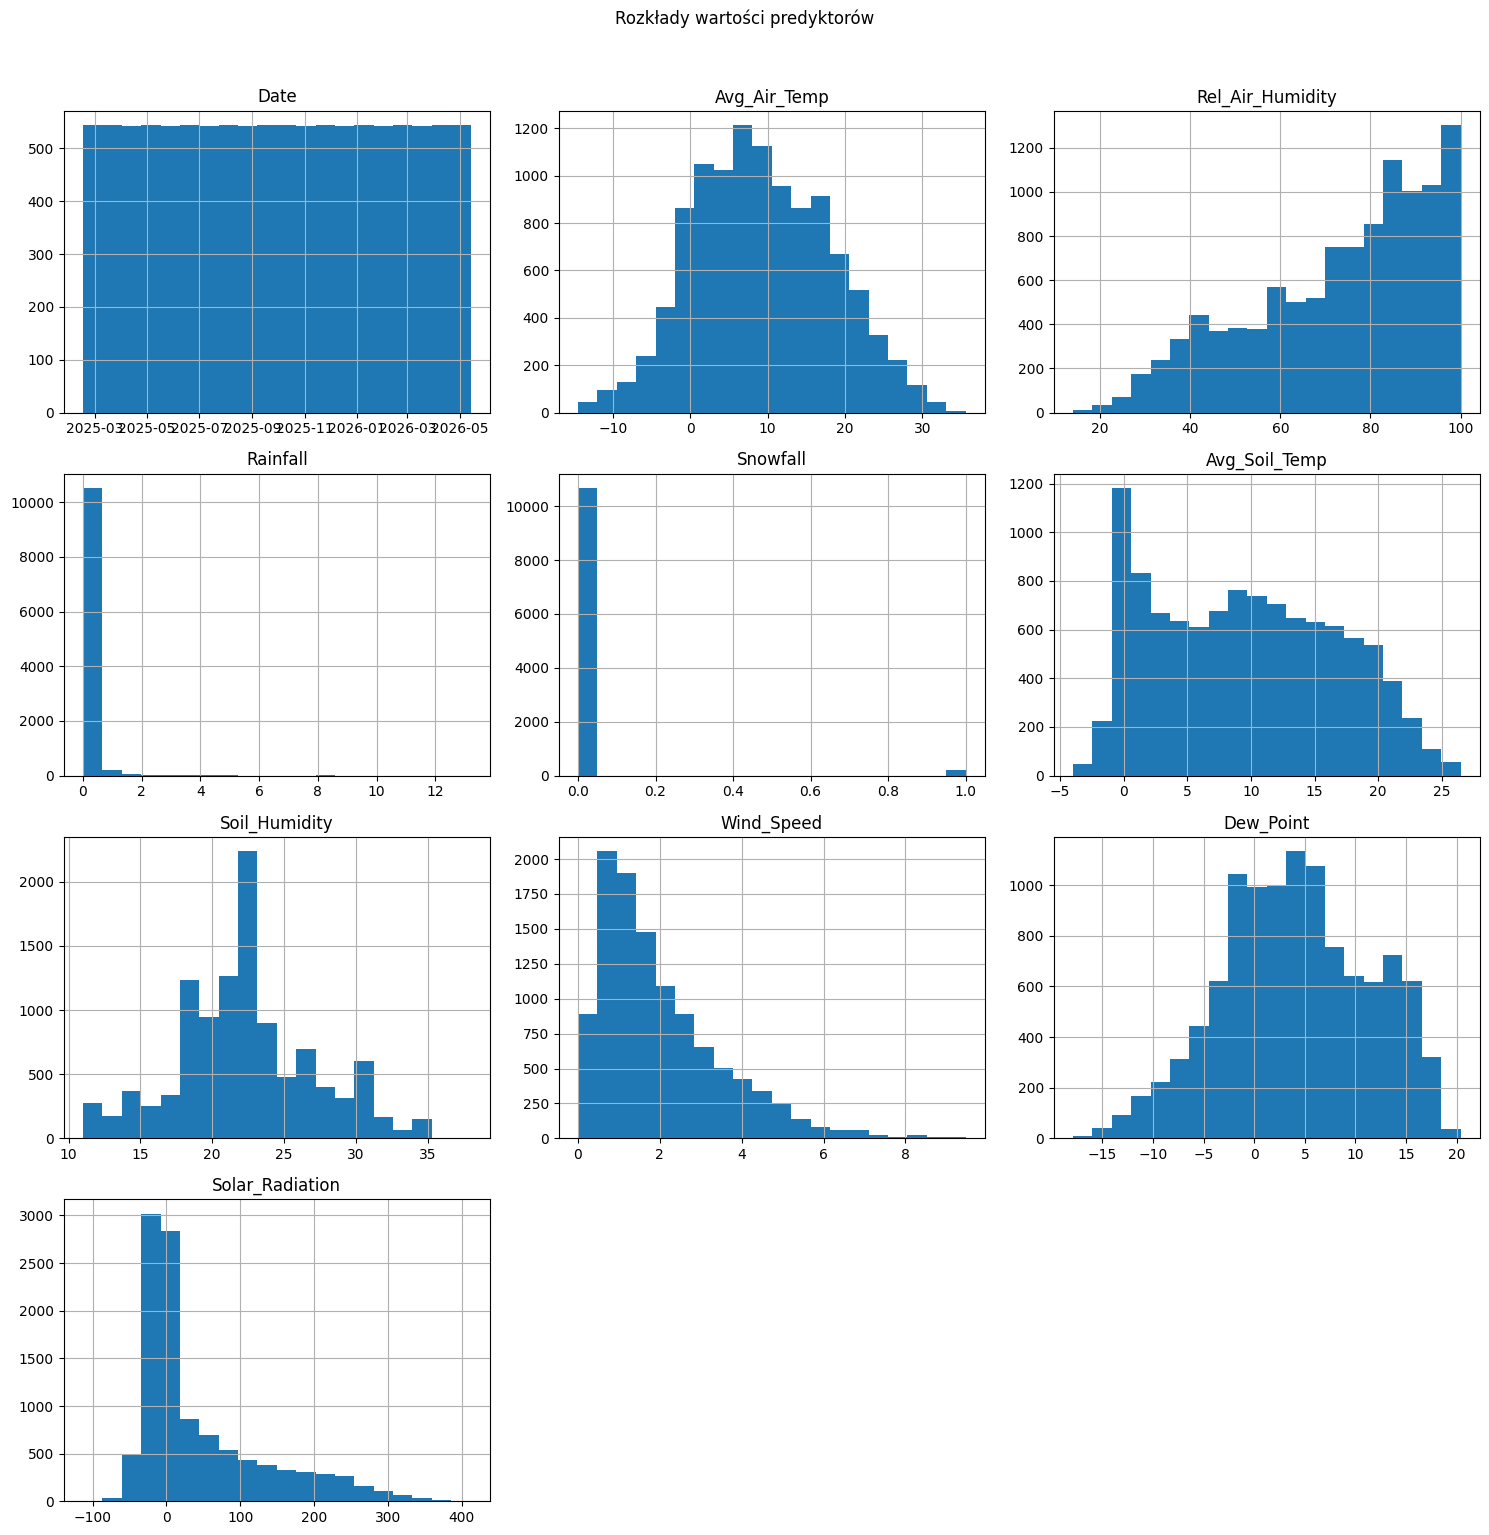

In [51]:
import matplotlib.pyplot as plt
df.hist(
    bins=20,
    figsize=(15, 15)
)

plt.suptitle("Rozkłady wartości predyktorów", y=1.02)
plt.tight_layout()
plt.show()

In [46]:
df.describe()

,Date,Avg_Air_Temp,Rel_Air_Humidity,Rainfall,Snowfall,Avg_Soil_Temp,Soil_Humidity,Wind_Speed,Dew_Point,Solar_Radiation
count,10872,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000,10872.000000
mean,2025-09-29 11:30:00,9.293344,73.275570,0.068889,0.018580,9.554778,22.359180,2.010708,4.116890,44.375920
min,2025-02-15 00:00:00,-14.540000,14.000000,0.000000,0.000000,-3.970000,11.000000,0.000000,-17.890000,-113.000000
25%,2025-06-08 05:45:00,2.640000,59.000000,0.000000,0.000000,3.060000,20.000000,0.890000,-1.190000,-13.000000
50%,2025-09-29 11:30:00,8.735000,78.000000,0.000000,0.000000,9.280000,22.000000,1.590000,4.060000,2.000000
75%,2026-01-20 17:15:00,15.810000,90.000000,0.000000,0.000000,15.320000,25.000000,2.760000,9.630000,80.000000
max,2026-05-13 23:00:00,35.600000,100.000000,13.200000,1.000000,26.470000,38.000000,9.470000,20.380000,412.000000
std,NaN,8.818462,20.050553,0.361028,0.135042,7.105097,4.761909,1.484176,7.308095,86.805559


In [47]:
import seaborn as sns
def plot_box_strip(df, variables, hue=None):
    """
    Box plots with overlaid observation points for the given variables.
    Parametry:
    - df: DataFrame zawierający dane,
    - variables: lista nazw kolumn ze zmiennymi ilościowymi,
    - hue: opcjonalna zmienna grupująca.
    """

    for var in variables:
        plt.figure(figsize=(8, 6))

        sns.boxplot(
            data=df,
            y=var,
            x=hue,
            fliersize=0,
            color="green"
        )

        sns.stripplot(
            data=df,
            y=var,
            x=hue,
            jitter=0.1,
            alpha=0.3,
            color="black"
        )

        plt.title(f"Wykres pudełkowy z obserwacjami: {var}")
        plt.xlabel(hue if hue else "")
        plt.ylabel(var)
        plt.tight_layout()
        plt.show()

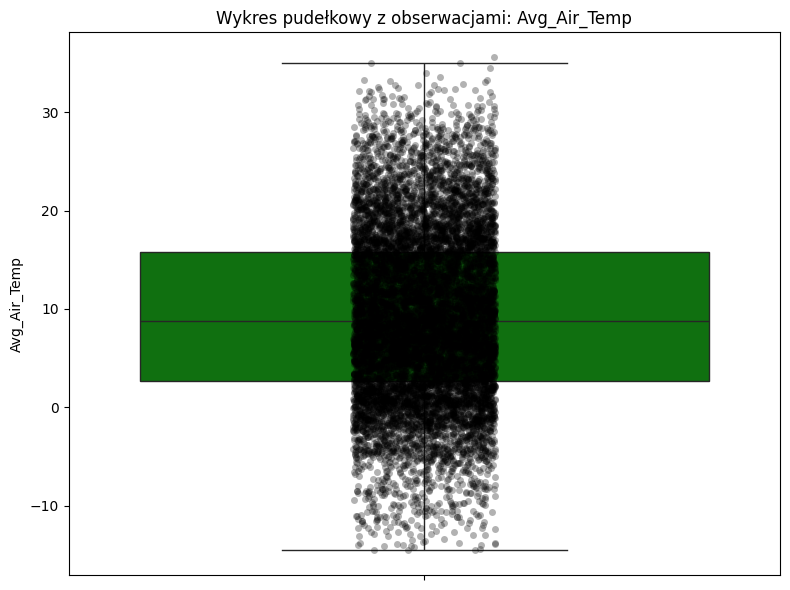

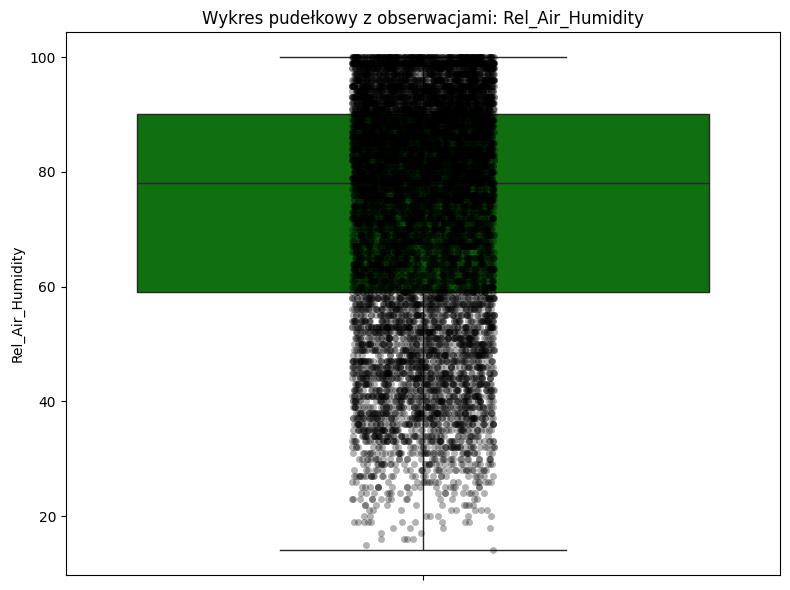

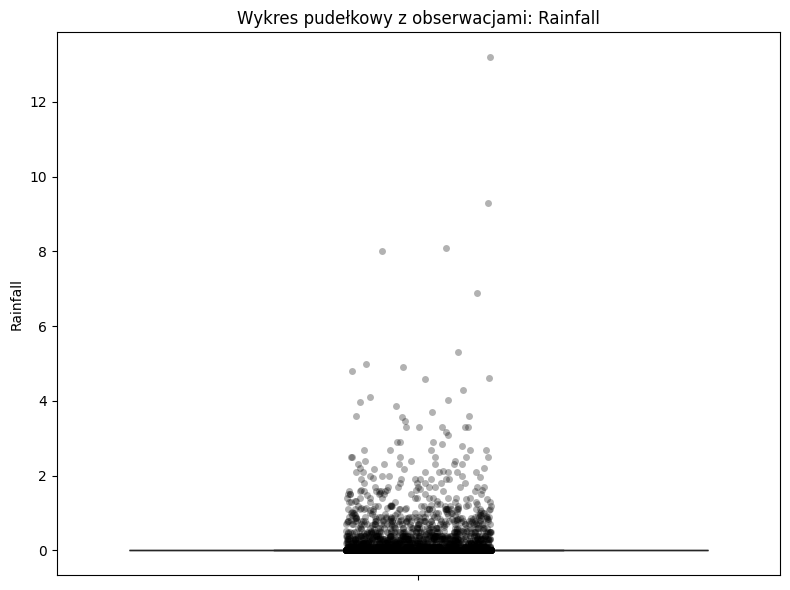

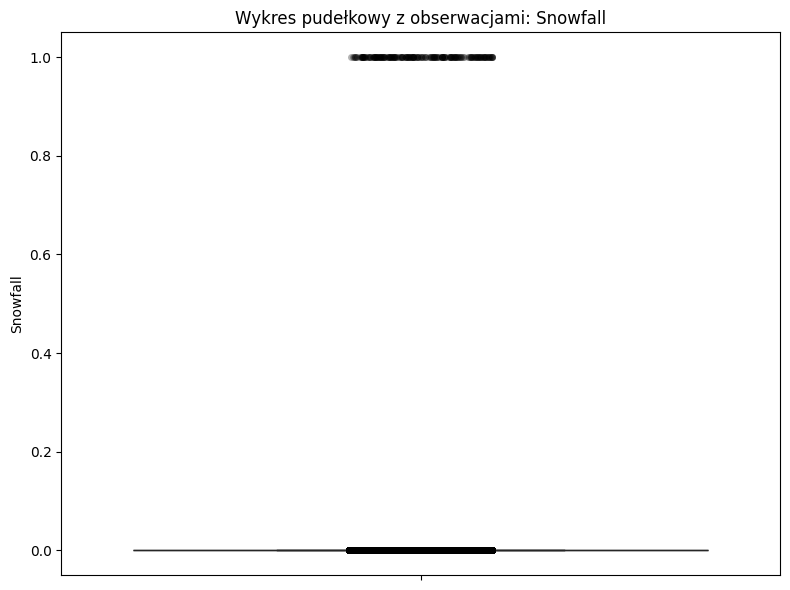

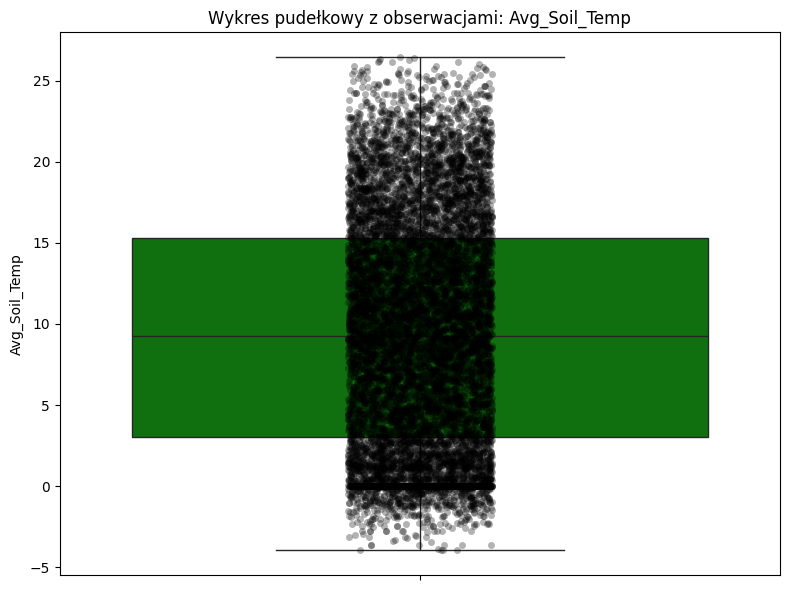

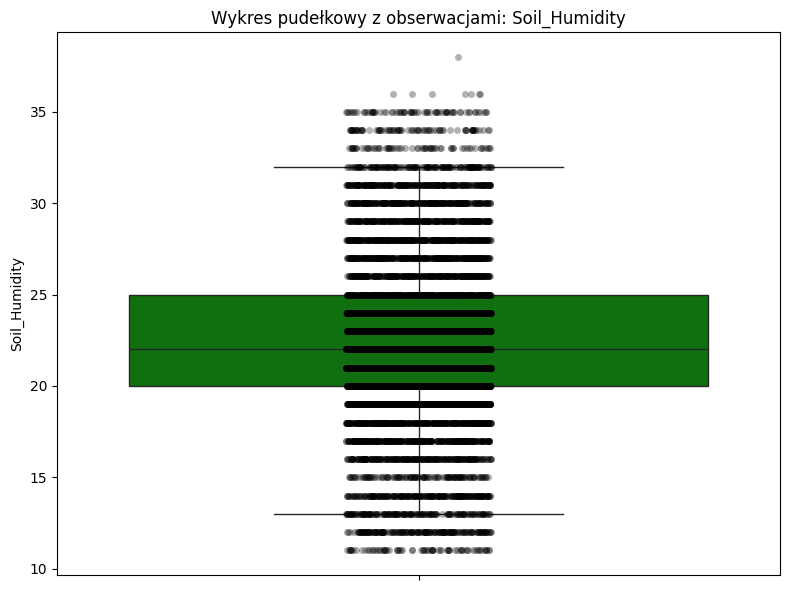

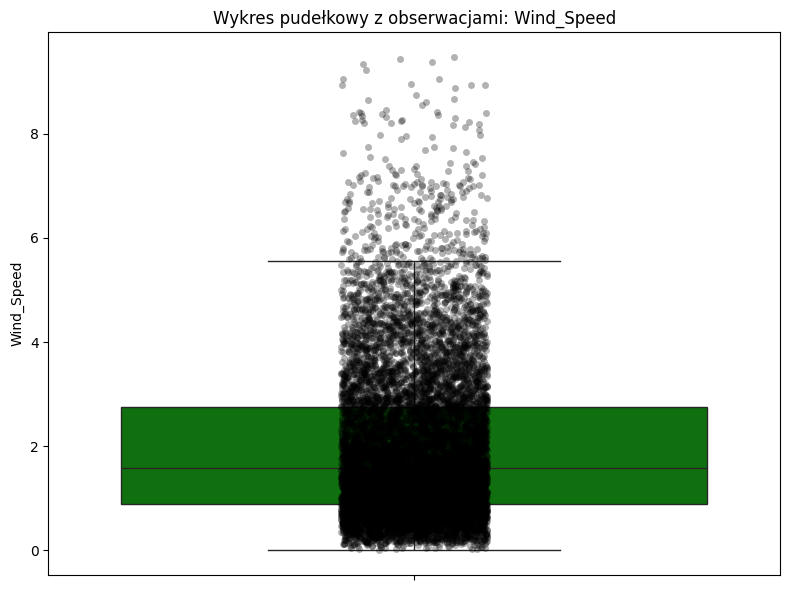

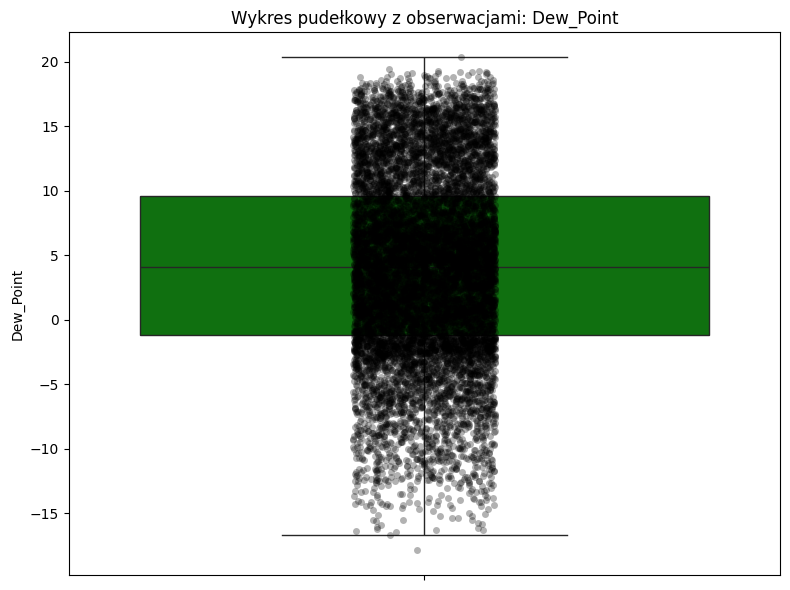

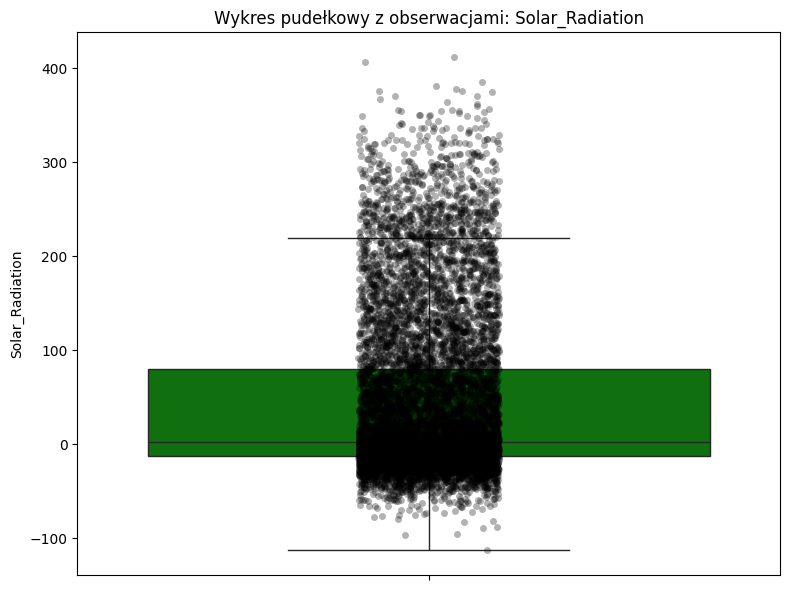

In [52]:
plot_box_strip(df, variables=df.columns[1:])

Mamy tylko jedną zmienną kategoryczną: Snowfall. Dla niej nie zauważamy raczej bardzo rzadkiej którejś z wartości. Reszta to zmienne numeryczne.